El gobierno de la provincia de Misiones lo ha contratado para realizar una apli-
caci ́on que sea capaz de detectar zonas deforestadas. Para desarrollar un primer
prototipo le han suministrado una imagen satelital (Deforestacion.png) en la
que un experto ya delimit ́o el  ́area donde deber ́ıa existir monte nativo y sobre
la cual usted debe trabajar. Se requiere que su aplicaci ́on:
- Segmente y resalte en alg ́un tono de rojo el  ́area deforestada.
- Calcule el  ́area total (hect ́areas) de la zona delimitada, el  ́area de la zona
que tiene monte y el  ́area de la zona deforestada.
- (Opcional) Detecte autom ́aticamente la delimitaci ́on de la zona.
Ayuda:
•Explore todos los canales de los diferentes modelos de color para determinar
cual (o que combinaci ́on de ellos) le proporciona m ́as informaci ́on.
•Como su objetivo es la segmentaci ́on de las distintas zonas, piense que her-
ramienta (de las que ya conoce) le permitir ́ıa lograr zonas m ́as homog ́eneas.
•Utilice la referencia de la esquina inferior izquierda para computar los tama ̃nos
de las regiones.
4

In [182]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

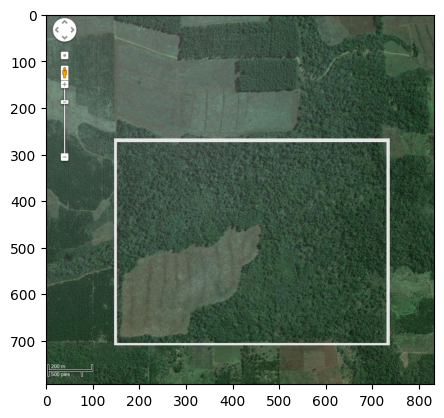

In [183]:
img = cv2.cvtColor(cv2.imread("../Imagenes_cursado/deforestacion.png"), cv2.COLOR_BGR2RGB)


plt.imshow(img)
plt.show()


# detección de roi

{'x': [267, 706], 'y': [146, 730]}


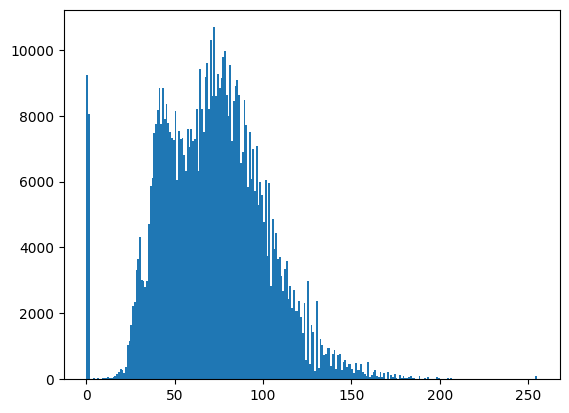

In [184]:
img_hsv = cv2.cvtColor(cv2.imread("../Imagenes_cursado/deforestacion.png"), cv2.COLOR_BGR2HSV)
# paso 1: Deteccion automatica de la zona (considerar blanco)

h, s, v = cv2.split(img_hsv)

#buscamos la saturacion baja para que sea blanco
plt.hist(np.ravel(s[:]), bins = 255)

limites = {
    "x": [],
    "y": []
}

encontro = False

for i in range(s.shape[0]):
    cond = (np.mean(s[i,:] < 20) > 0.6) and (np.mean(v[i,:] > 200) > 0.6)
    if cond and not encontro:
        encontro = True
        limites["x"].append(i)   

    elif not cond and encontro:
        encontro = False

encontro = False

for i in range(s.shape[0]):
    cond = (np.mean(s[:,i] < 20) > 0.5) and (np.mean(v[:,i] > 200) > 0.5)
    if cond and not encontro:
        encontro = True
        limites["y"].append(i)   

    elif not cond and encontro:
        encontro = False
print(limites)


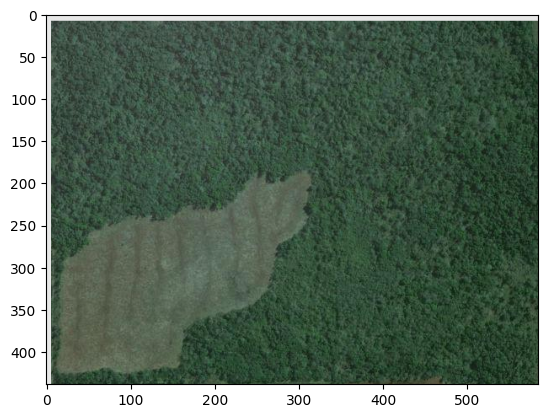

In [185]:
roi_h = h[limites["x"][0]: limites["x"][1],limites["y"][0]: limites["y"][1]]
roi_s = s[limites["x"][0]: limites["x"][1],limites["y"][0]: limites["y"][1]]
roi_v = v[limites["x"][0]: limites["x"][1],limites["y"][0]: limites["y"][1]]

hsv_roi = cv2.merge([roi_h, roi_s, roi_v])

plt.imshow(cv2.cvtColor(hsv_roi, cv2.COLOR_HSV2RGB))
plt.show()



# preprocesamiento de la imagen

Aplicamos filtro gaussiano para homogeneizar las zonas homogeneas


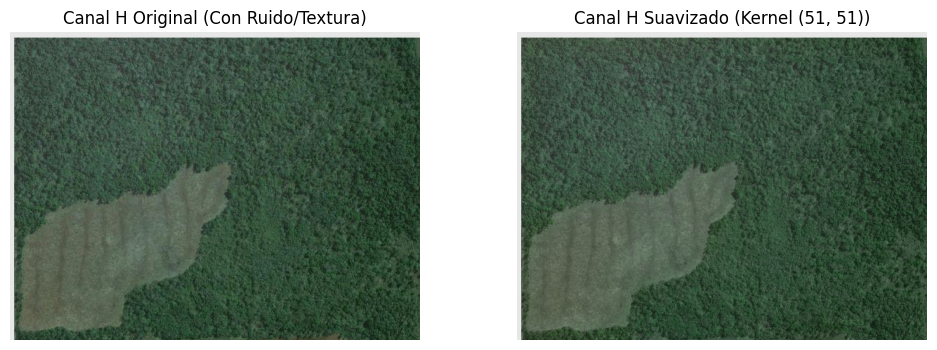

In [186]:
h_roi, s_roi, v_roi = cv2.split(hsv_roi)

ksize = (51,51)

h_blur = cv2.GaussianBlur(h_roi, ksize, 50)
h_blur = cv2.GaussianBlur(h_blur, ksize, 50) #aplicamos filtro dos veces




procesed_hsv = cv2.merge([h_blur, s_roi, v_roi])

fig, axs = plt.subplots(1,2, figsize = (12,4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(hsv_roi, cv2.COLOR_HSV2RGB))
plt.title('Canal H Original (Con Ruido/Textura)')
plt.axis('off')

# Imagen Suavizada (Canal H)
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(procesed_hsv, cv2.COLOR_HSV2RGB))
plt.title(f'Canal H Suavizado (Kernel {ksize})')
plt.axis('off')

plt.show()

# umbralización- detección

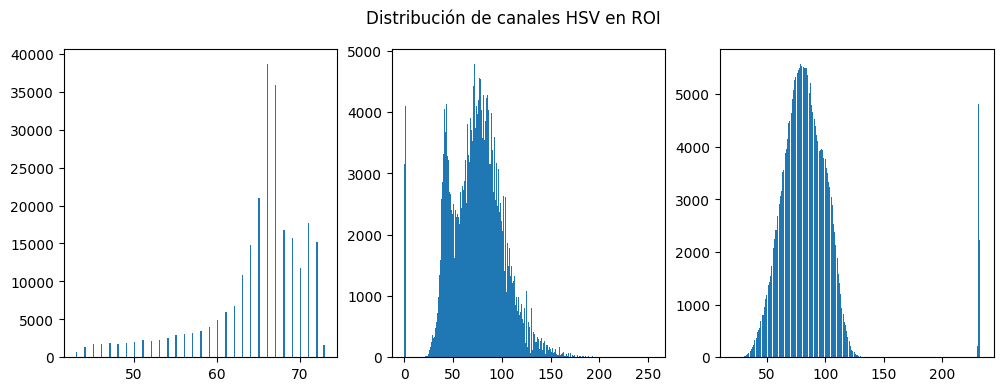

In [187]:
h_roi, s_roi, v_roi = cv2.split(procesed_hsv)
fig, axs = plt.subplots(1,3, figsize = (12,4))
axs[0].hist(np.ravel(h_roi), bins = 180)
axs[1].hist(np.ravel(s_roi), bins = 255)
axs[2].hist(np.ravel(v_roi), bins = 255)
fig.suptitle("Distribución de canales HSV en ROI")


#buscamos roi deforestado

#sacas la media de los colores de una muestra, como no la tengo la saco de esta foto!
sample_h = h_roi[300:400, 50:100]
sample_s = s_roi[300:400, 50:100]
sample_v = v_roi[300:400, 50:100]

mean_h = np.mean(np.ravel(sample_h))
mean_s = np.mean(np.ravel(sample_s))
mean_v = np.mean(np.ravel(sample_v))


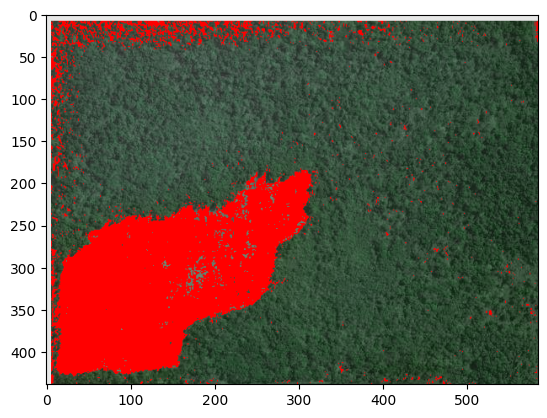

In [188]:
distancia = np.sqrt((h_roi - mean_h)**2 + (s_roi - mean_s)**2 + (v_roi - mean_v)**2)

# Umbral de distancia (ajústalo experimentalmente)
threshold_dist = 25
mask_final = distancia <= threshold_dist

# Colorear
#colored_hsv = cv2.cvtColor(procesed_hsv, cv2.COLOR_HSV2BGR)
procesed_hsv[mask_final]=[0, 255,255]

img_coloreada = cv2.cvtColor(procesed_hsv, cv2.COLOR_HSV2RGB)

plt.imshow(img_coloreada)
plt.show()

# Calculo de areas

Aproximada mente100 pixeles horizontales son 200metros

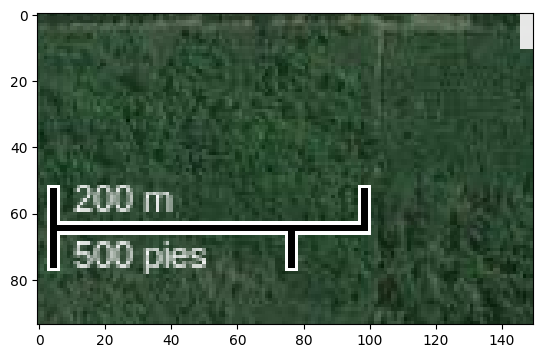

In [190]:
plt.imshow(img[700:,0:150,:])

contamos cuantos pixeles de la roi superan umbral de rojo

si 
- 200*200 m**2 -> 100* 100 pixeles
- m*2? -> num_rojos



In [194]:
num_rojos =np.sum(mask_final)
print(num_rojos)

print(f"{num_rojos * (200 * 200) / 100 * 100} m**2")

46640
1865600000.0 m**2
